#**Thyroid Disease Data - Clasificación**

## **Integrantes:**

* Mariamny Del Valle Ramírez Telles
* David Alejandro Gutiérrez Leal
* Sahian Salomé Gutiérrez Ossa


**Link Dataset:**
https://www.kaggle.com/datasets/jainaru/thyroid-disease-data/data

# **Fase 1 — EDA, limpieza y preprocesamiento (aplica a ambos datasets)**

###**Punto 1:**
Lea la documentación de cada dataset y describa el problema de negocio/salud que representa, e identifique cuál es la
variable objetivo (target) en cada caso.

El dataset representa un **problema de predicción de recurrencia del cáncer diferenciado de tiroides**. Contiene información clínica y características de pacientes diagnosticados con este tipo de cáncer, como edad, género, antecedentes de tabaquismo y radioterapia, características del tumor, clasificación del riesgo, presencia de metástasis, respuesta al tratamiento, entre otras.

El objetivo es utilizar estas características para predecir si un paciente tendrá una recurrencia del cáncer después del tratamiento inicial. Esto puede apoyar a los profesionales de la salud en la identificación de pacientes que podrían necesitar un seguimiento más frecuente o una atención adicional.


La **variable objetivo (target)** es **Recurred,** ya que indica si el paciente presentó recurrencia del cáncer después del tratamiento. Esta variable puede tomar los valores Yes (sí recurrió) o No (no recurrió).

Por lo tanto, se trata de un problema de clasificación binaria, donde las variables clínicas y demográficas del paciente se utilizan como variables predictoras y Recurred como variable objetivo.

###**Punto 2:**
Cargue el dataset con pandas, muestre head()/tail(), .shape y .info(). Construya el diccionario de datos (columna, tipo
esperado, significado).

In [32]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import cross_validate, StratifiedKFold, train_test_split

In [33]:
# Set the path to the file you'd like to load
file_path = "Thyroid_Diff.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "jainaru/thyroid-disease-data",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

/tmp/ipykernel_1840/3835193126.py:5: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'thyroid-disease-data' dataset.


In [34]:
df.head()

,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Indeterminate,No
1,34,F,No,Yes,No,Euthyroid,Multinodular goiter,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
2,30,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
3,62,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
4,62,F,No,No,No,Euthyroid,Multinodular goiter,No,Micropapillary,Multi-Focal,Low,T1a,N0,M0,I,Excellent,No


In [35]:
df.tail()

,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
378,72,M,Yes,Yes,Yes,Euthyroid,Single nodular goiter-right,Right,Papillary,Uni-Focal,High,T4b,N1b,M1,IVB,Biochemical Incomplete,Yes
379,81,M,Yes,No,Yes,Euthyroid,Multinodular goiter,Extensive,Papillary,Multi-Focal,High,T4b,N1b,M1,IVB,Structural Incomplete,Yes
380,72,M,Yes,Yes,No,Euthyroid,Multinodular goiter,Bilateral,Papillary,Multi-Focal,High,T4b,N1b,M1,IVB,Structural Incomplete,Yes
381,61,M,Yes,Yes,Yes,Clinical Hyperthyroidism,Multinodular goiter,Extensive,Hurthel cell,Multi-Focal,High,T4b,N1b,M0,IVA,Structural Incomplete,Yes
382,67,M,Yes,No,No,Euthyroid,Multinodular goiter,Bilateral,Papillary,Multi-Focal,High,T4b,N1b,M0,IVA,Structural Incomplete,Yes


In [36]:
df.shape

(383, 17)

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383 entries, 0 to 382
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Age                   383 non-null    int64 
 1   Gender                383 non-null    object
 2   Smoking               383 non-null    object
 3   Hx Smoking            383 non-null    object
 4   Hx Radiothreapy       383 non-null    object
 5   Thyroid Function      383 non-null    object
 6   Physical Examination  383 non-null    object
 7   Adenopathy            383 non-null    object
 8   Pathology             383 non-null    object
 9   Focality              383 non-null    object
 10  Risk                  383 non-null    object
 11  T                     383 non-null    object
 12  N                     383 non-null    object
 13  M                     383 non-null    object
 14  Stage                 383 non-null    object
 15  Response              383 non-null    ob

# Diccionario de Datos — Thyroid Cancer Recurrence Dataset

| # | Columna | Tipo (pandas) | Tipo esperado | Significado |
|---|---------|---------------|---------------|-------------|
| 0 | Age | int64 | Numérico (entero) | Edad del paciente al momento del diagnóstico o tratamiento. |
| 1 | Gender | object | Categórico binario | Género del paciente (M = male, F = female). |
| 2 | Smoking | object | Categórico binario | Indica si el paciente es fumador actualmente (Yes/No). |
| 3 | Hx Smoking | object | Categórico binario | Historial de tabaquismo (si alguna vez ha fumado, aunque ya no fume) (Yes/No). |
| 4 | Hx Radiothreapy | object | Categórico binario | Historial de radioterapia previa por cualquier condición (Yes/No). |
| 5 | Thyroid Function | object | Categórico nominal | Estado funcional de la tiroides (p. ej. Euthyroid, Hypothyroidism, Hyperthyroidism, Subclinical Hypo/Hyperthyroidism). |
| 6 | Physical Examination | object | Categórico nominal | Hallazgos del examen físico de la tiroides (p. ej. Normal, Multinodular goiter, Single nodular goiter-left/right, Diffuse goiter). |
| 7 | Adenopathy | object | Categórico nominal | Presencia/ubicación de adenopatía (ganglios linfáticos agrandados) en el cuello (No, Right, Left, Bilateral, Posterior, Extensive). |
| 8 | Pathology | object | Categórico nominal | Tipo histológico de cáncer de tiroides según biopsia (Papillary, Micropapillary, Follicular, Hurthel cell). |
| 9 | Focality | object | Categórico binario | Si el tumor es unifocal (una sola localización) o multifocal (varias). |
| 10 | Risk | object | Categórico ordinal | Categoría de riesgo del cáncer (Low, Intermediate, High), según tamaño, extensión e histología. |
| 11 | T | object | Categórico ordinal | Clasificación TNM — tamaño e invasión local del tumor primario (T1a, T1b, T2, T3a, T3b, T4a, T4b). |
| 12 | N | object | Categórico ordinal | Clasificación TNM — afectación de ganglios linfáticos regionales (N0, N1a, N1b). |
| 13 | M | object | Categórico binario | Clasificación TNM — presencia de metástasis a distancia (M0, M1). |
| 14 | Stage | object | Categórico ordinal | Estadio global del cáncer, combinando T, N y M (I, II, III, IVA, IVB). |
| 15 | Response | object | Categórico nominal | Respuesta al tratamiento (Excellent, Indeterminate, Biochemical Incomplete, Structural Incomplete). |
| 16 | Recurred | object | Categórico binario | Indica si el cáncer reincidió después del tratamiento inicial (Yes/No). |

**Notas generales**
- El dataset tiene 383 registros y 17 columnas, sin valores nulos (`Non-Null Count` = 383 en todas).
- Las variables T, N, M y Stage siguen el sistema de estadificación TNM del AJCC para cáncer de tiroides diferenciado.

**Punto 3:** .describe() para las columnas numéricas. Interprete al menos 3 estadísticos por dataset en términos del problema.

In [38]:
df.describe()

,Age
count,383.000000
mean,40.866841
std,15.134494
min,15.000000
25%,29.000000
50%,37.000000
75%,51.000000
max,82.000000


La variable Age es la única variable numérica del dataset, por lo que es la única que aparece en el resultado de describe().

Count = 383: hay 383 registros con la edad registrada, por lo que no se presentan datos faltantes en esta variable.
Mean = 40.87: la edad promedio de los pacientes es aproximadamente 41 años.
Std = 15.13: la desviación estándar muestra que las edades tienen una variación considerable alrededor del promedio.
Min = 15 y Max = 82: las edades de los pacientes están entre los 15 y los 82 años, por lo que existe un rango amplio de edades.
Percentiles: el 25% de los pacientes tiene 29 años o menos, el 50% tiene 37 años o menos y el 75% tiene 51 años o menos. Como la media (40.87) es mayor que la mediana (37), se puede observar que algunos pacientes de mayor edad hacen que el promedio aumente.

En general, el dataset contiene pacientes de diferentes edades, aunque una parte importante se encuentra entre los 29 y 51 años.

###**Punto 4:**
 Identifique valores nulos por columna, calcule su porcentaje, y proponga una estrategia de imputación o eliminación. Justifique la elección según el porcentaje de nulos y el tipo de variable (¿es razonable imputar con la media? ¿con la moda? ¿es mejor eliminar la fila o la columna?).

In [39]:
null_counts = df.isnull().sum()
null_percentages = (df.isnull().sum() / len(df)) * 100

null_info = pd.DataFrame({
    'Null Count': null_counts,
    'Null Percentage': null_percentages
})

null_info

,Null Count,Null Percentage
Age,0,0.0
Gender,0,0.0
Smoking,0,0.0
Hx Smoking,0,0.0
Hx Radiothreapy,0,0.0
Thyroid Function,0,0.0
Physical Examination,0,0.0
Adenopathy,0,0.0
Pathology,0,0.0
Focality,0,0.0


Como se observa en el resultado anterior y se confirmó con `df.info()`, el dataset no presenta valores nulos en ninguna de sus columnas. Por lo tanto, no es necesario aplicar ninguna estrategia de imputación o eliminación de nulos.

###**Punto 5:**
Identifique y elimine duplicados si existen. Reporte cuántos se eliminaron.

In [40]:
num_duplicates = df.duplicated().sum()
print(f"Número de filas duplicadas encontradas: {num_duplicates}")

if num_duplicates > 0:
    df_cleaned = df.drop_duplicates().reset_index(drop=True)
    print(f"Se eliminaron {num_duplicates} filas duplicadas.")
    print(f"Nueva forma del DataFrame: {df_cleaned.shape}")
else:
    df_cleaned = df.copy() # Crear una copia para mantener la coherencia en la nomenclatura de las variables.
    print("No se encontraron filas duplicadas.")

df_cleaned.head()

Número de filas duplicadas encontradas: 19
Se eliminaron 19 filas duplicadas.
Nueva forma del DataFrame: (364, 17)


,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Indeterminate,No
1,34,F,No,Yes,No,Euthyroid,Multinodular goiter,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
2,30,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
3,62,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
4,62,F,No,No,No,Euthyroid,Multinodular goiter,No,Micropapillary,Multi-Focal,Low,T1a,N0,M0,I,Excellent,No


Dado que el dataset no cuenta con un identificador único de paciente, la detección de duplicados se basa en la coincidencia exacta de las 17 variables clínicas. Esto podría eliminar registros de pacientes distintos que comparten el mismo perfil clínico, en lugar de errores reales de captura. Se optó por eliminarlos de todas formas asumiendo que, dada la baja probabilidad de coincidencia exacta en 17 variables simultáneamente, es más razonable tratarlos como duplicados verdadero

###Punto 6
Revise inconsistencias de formato en columnas categóricas o de texto (mayúsculas/minúsculas, espacios, etiquetas
equivalentes) y corríjalas

In [41]:
print('Columnas categóricas (tipo object) y sus valores únicos:')
for col in df_cleaned.select_dtypes(include='object').columns:
    print(f"\nColumna '{col}':")
    print(df_cleaned[col].unique())


for col in df_cleaned.select_dtypes(include='object').columns:
    valores = df_cleaned[col].unique()
    # Compara cada valor con su versión limpia (sin espacios extra)
    con_espacios = [v for v in valores if v != v.strip()]
    if con_espacios:
        print(f"Columna '{col}' tiene valores con espacios extra: {con_espacios}")

print("Verificación completada.")

Columnas categóricas (tipo object) y sus valores únicos:

Columna 'Gender':
['F' 'M']

Columna 'Smoking':
['No' 'Yes']

Columna 'Hx Smoking':
['No' 'Yes']

Columna 'Hx Radiothreapy':
['No' 'Yes']

Columna 'Thyroid Function':
['Euthyroid' 'Clinical Hyperthyroidism' 'Clinical Hypothyroidism'
 'Subclinical Hyperthyroidism' 'Subclinical Hypothyroidism']

Columna 'Physical Examination':
['Single nodular goiter-left' 'Multinodular goiter'
 'Single nodular goiter-right' 'Normal' 'Diffuse goiter']

Columna 'Adenopathy':
['No' 'Right' 'Extensive' 'Left' 'Bilateral' 'Posterior']

Columna 'Pathology':
['Micropapillary' 'Papillary' 'Follicular' 'Hurthel cell']

Columna 'Focality':
['Uni-Focal' 'Multi-Focal']

Columna 'Risk':
['Low' 'Intermediate' 'High']

Columna 'T':
['T1a' 'T1b' 'T2' 'T3a' 'T3b' 'T4a' 'T4b']

Columna 'N':
['N0' 'N1b' 'N1a']

Columna 'M':
['M0' 'M1']

Columna 'Stage':
['I' 'II' 'IVB' 'III' 'IVA']

Columna 'Response':
['Indeterminate' 'Excellent' 'Structural Incomplete'
 'Biochemi

Al revisar los valores únicos de las columnas categóricas, no se observan inconsistencias obvias como diferentes usos de mayúsculas/minúsculas para la misma categoría, espacios extra o etiquetas equivalentes que necesiten unificación. Los valores parecen estar limpios y bien definidos para cada categoría.

###Punto 7
Identifique outliers en al menos dos columnas numéricas relevantes usando el criterio IQR. Repórtelos y decida si se tratan o se documentan sin eliminar, justificando la decisión (¿tienen sentido de negocio, como vuelos de última hora muy caros, o son errores de captura?).

In [42]:
# Identificar columnas numéricas
numeric_cols = df_cleaned.select_dtypes(include=['int64', 'float64']).columns
print(f"Columnas numéricas identificadas: {list(numeric_cols)}")

if 'Age' in numeric_cols:
    col = 'Age'
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_cleaned[(df_cleaned[col] < lower_bound) | (df_cleaned[col] > upper_bound)]

    print(f"\nOutliers en la columna '{col}':")
    if not outliers.empty:
        print(f"Se encontraron {len(outliers)} outliers en '{col}'.")
        outliers[[col]]
    else:
        print(f"No se encontraron outliers en la columna '{col}' usando el criterio IQR.")
else:
    print("La columna 'Age' no fue encontrada o no es numérica.")

Columnas numéricas identificadas: ['Age']

Outliers en la columna 'Age':
No se encontraron outliers en la columna 'Age' usando el criterio IQR.


Dado que Age es la única columna numérica en el dataset, se realizó el análisis de outliers utilizando el criterio IQR solo para esta columna. No se encontraron outliers, lo que sugiere que las edades de los pacientes están dentro de un rango esperado y no hay valores extremadamente atípicos que puedan ser considerados errores de captura. Las edades de los pacientes varían entre 15 y 82, lo cual es un rango plausible para una población médica.

### Punto 8
Genere las gráficas de EDA (barras, pie, histograma, scatter plot y boxplot) para las variables relevantes de cada
dataset. Para cada gráfica incluya el código, la imagen y un párrafo de interpretación con una recomendación como
responsable de la toma de decisiones.

/tmp/ipykernel_1840/2750961958.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Gender', data=df_cleaned, palette='viridis')


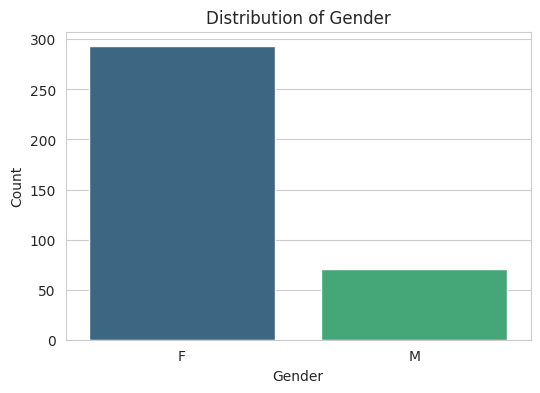

In [43]:
# Estilo de plots
sns.set_style("whitegrid")

# Distribucion de género

plt.figure(figsize=(6, 4))
sns.countplot(x='Gender', data=df_cleaned, palette='viridis')
plt.title('Distribution of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

### Interpretación y Recomendación (Género)

**Interpretación:** La gráfica de barras muestra la distribución de género en el dataset. Se observa que hay un mayor número de pacientes de género 'F' (Female) en comparación con 'M' (Male).

**Recomendación:** Es importante tener en cuenta esta distribución al construir modelos, ya que un desequilibrio significativo en el género podría influir en las predicciones si el cáncer de tiroides tiene diferentes prevalencias o comportamientos según el género. Si el desbalance es muy grande y se sospecha que el género es un factor relevante, se podría considerar técnicas de sobremuestreo o submuestreo durante el entrenamiento del modelo para evitar que el modelo esté sesgado hacia la categoría mayoritaria.

/tmp/ipykernel_1840/2449658466.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Recurred', data=df_cleaned, palette='coolwarm')


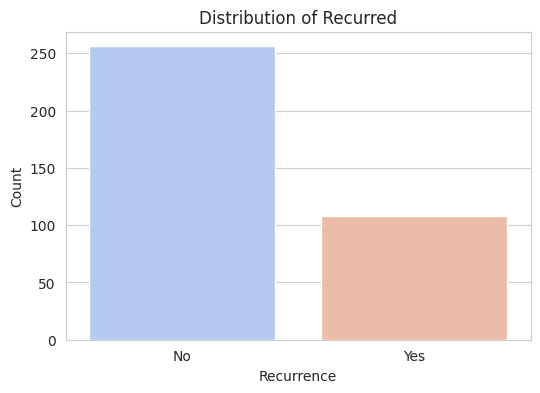

In [44]:
# Distribucion de Recurred (Target Variable)
plt.figure(figsize=(6, 4))
sns.countplot(x='Recurred', data=df_cleaned, palette='coolwarm')
plt.title('Distribution of Recurred')
plt.xlabel('Recurrence')
plt.ylabel('Count')
plt.show()

### Interpretación y Recomendación (Variable Objetivo: Recurred)

**Interpretación:** Esta gráfica de barras muestra el desequilibrio de clases en la variable objetivo 'Recurred'. Claramente, hay más casos de 'No' recurrencia que de 'Yes' recurrencia. Este es un problema de clases desbalanceadas.

**Recomendación:** Dado el desbalance de clases, es crucial no confiar únicamente en la exactitud (accuracy) como métrica de evaluación del modelo. Se deben priorizar métricas como la **precisión (precision), recall (sensibilidad), F1-score** y la **curva ROC-AUC**. Durante el entrenamiento del modelo, se deberían aplicar técnicas para manejar el desbalance de clases, como el sobremuestreo de la clase minoritaria (ej. SMOTE), submuestreo de la clase mayoritaria, o el uso de algoritmos que manejen bien este tipo de datasets (ej. modelos basados en árboles con pesos de clase).

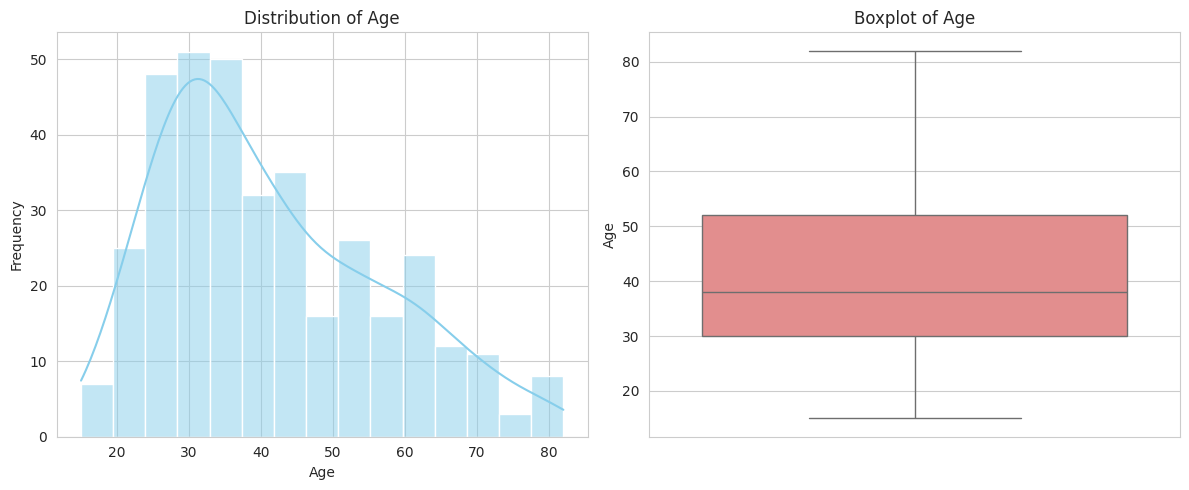

In [45]:
# Distribucion de Age

# Histograma
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
sns.histplot(df_cleaned['Age'], kde=True, bins=15, color='skyblue')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')

# Boxplot
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
sns.boxplot(y=df_cleaned['Age'], color='lightcoral')
plt.title('Boxplot of Age')
plt.ylabel('Age')

plt.tight_layout()
plt.show()

### Interpretación y Recomendación (Edad)

**Interpretación:** El histograma muestra que la distribución de la edad está ligeramente sesgada a la derecha, con la mayoría de los pacientes concentrados en edades más jóvenes a medias. El boxplot confirma que no hay outliers extremos (como se verificó previamente con el método IQR), y que las edades se distribuyen de manera razonable entre los 15 y 82 años, con la mitad de los pacientes entre 30 y 52 años aproximadamente.

**Recomendación:** La edad es una variable numéricamente bien comportada y sin outliers. Podría ser una característica importante para la predicción de recurrencia. Se recomienda mantenerla en el modelo, y su distribución normal (aunque ligeramente sesgada) permite que se use directamente

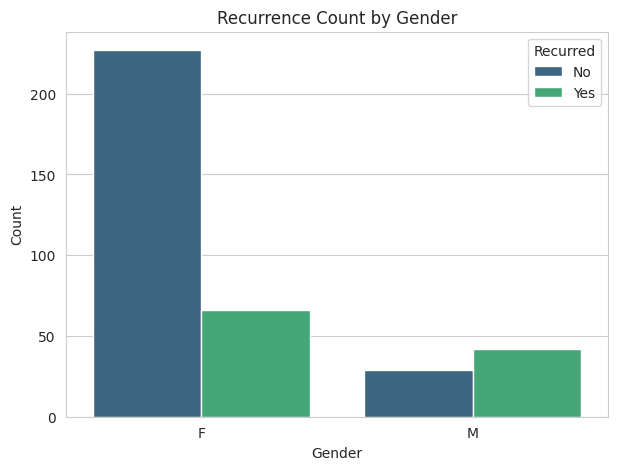

In [46]:
# Recurrence por Gender
plt.figure(figsize=(7, 5))
sns.countplot(x='Gender', hue='Recurred', data=df_cleaned, palette='viridis')
plt.title('Recurrence Count by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Recurred')
plt.show()

### Interpretación y Recomendación (Recurrencia por Género)

**Interpretación:** Se observa que, aunque hay más mujeres en el dataset, la proporción de recurrencia parece ser similar entre hombres y mujeres. Visualmente, el número absoluto de recurrencias ('Yes') es mayor en mujeres, pero esto podría deberse a que hay más mujeres en la muestra general.

**Recomendación:** Analizar las proporciones relativas de recurrencia dentro de cada grupo de género (porcentaje de mujeres con recurrencia vs. porcentaje de hombres con recurrencia) para determinar si el género es un factor significativo. Si las proporciones son similares, la variable de género podría no ser un predictor fuerte por sí sola, pero podría interactuar con otras variables. Mantener esta característica es apropiado.

### Gráfica de Pie (Distribución de Recurrence)

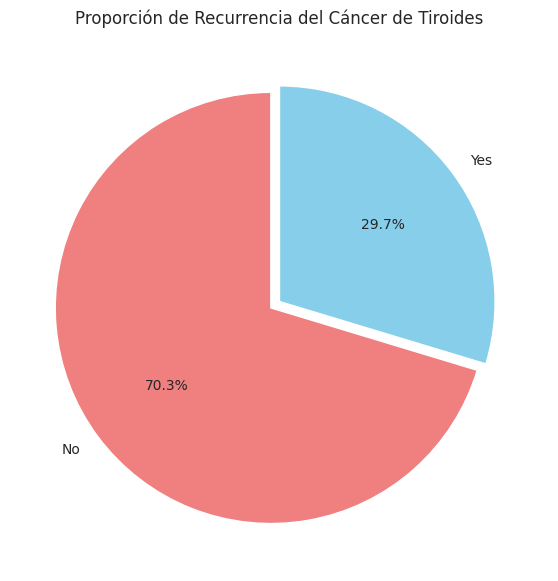

In [47]:
plt.figure(figsize=(7, 7))
df_cleaned['Recurred'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, colors=['lightcoral', 'skyblue'], explode=[0.05, 0])
plt.title('Proporción de Recurrencia del Cáncer de Tiroides')
plt.ylabel('') # Eliminar la etiqueta Recurred del eje Y para una vista más limpia
plt.show()

### Interpretación y Recomendación (Gráfico de Pie - Recurrence)

**Interpretación:** El gráfico de pastel confirma visualmente el desequilibrio de clases en la variable `Recurred`. Alrededor del 70% de los pacientes no experimentaron recurrencia, mientras que aproximadamente el 30% sí lo hizo. Esta representación clara del desbalance refuerza la necesidad de usar métricas adecuadas y técnicas de manejo de clases desbalanceadas.

**Recomendación:** Este tipo de visualización es excelente para comunicar rápidamente la magnitud del desequilibrio de clases a las partes interesadas (por ejemplo, personal médico o gestores del proyecto). Es una justificación visual adicional para la estrategia de priorizar el *Recall* y considerar técnicas de balanceo de datos en el modelado.

### Gráfico de Dispersión (Age vs. Risk)

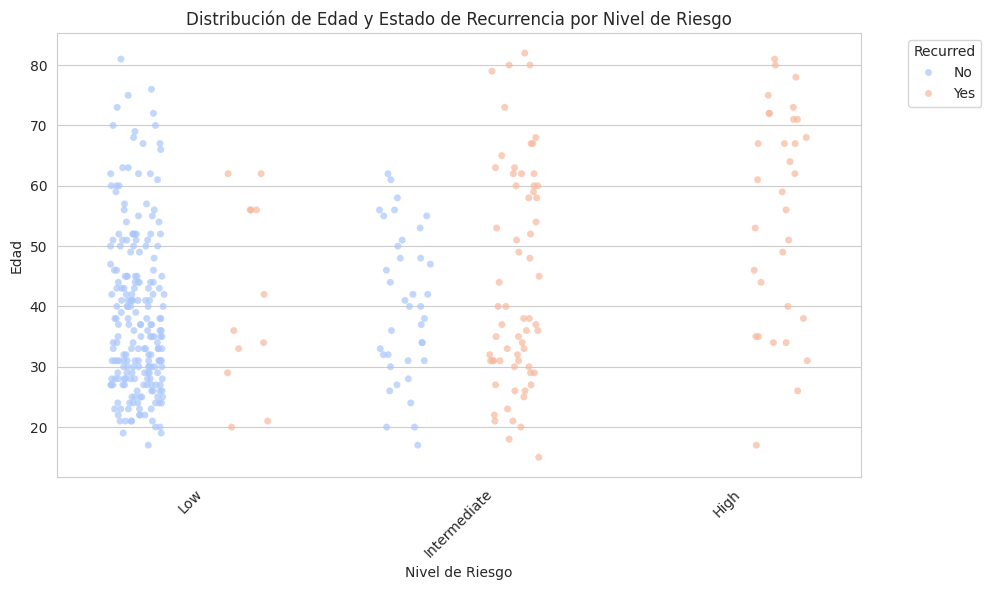

In [48]:
# Para el scatter plot, usaremos 'Age' y mapearemos la variable ordinal 'Risk' a un valor numérico temporal para la visualización.
# Esto nos permitirá ver la distribución de la edad dentro de cada categoría de riesgo.

# Crear una copia para evitar modificar el df_cleaned original para el mapeo
df_temp = df_cleaned.copy()

# Mapear 'Risk' a valores numéricos para visualización (solo si no se ha hecho ya de forma consistente)
# Si 'Risk' ya está codificada como ordinal en df_encoded y se quiere usar esa, se podría traer.
# Para esta visualización, haremos un mapeo explícito para controlar el orden.
risk_order_map = {'Low': 0, 'Intermediate': 1, 'High': 2}
df_temp['Risk_numeric'] = df_temp['Risk'].map(risk_order_map)

plt.figure(figsize=(10, 6))
sns.stripplot(x='Risk', y='Age', data=df_temp, hue='Recurred', palette='coolwarm', jitter=0.2, dodge=True, alpha=0.7)
plt.title('Distribución de Edad y Estado de Recurrencia por Nivel de Riesgo')
plt.xlabel('Nivel de Riesgo')
plt.ylabel('Edad')
plt.xticks(rotation=45)
plt.legend(title='Recurred', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Eliminar la columna temporal si no se va a usar más
del df_temp

### Interpretación y Recomendación (Gráfico de Dispersión - Age vs. Risk)

**Interpretación:** Este gráfico de dispersión, que utiliza un `stripplot` para manejar la superposición de puntos, muestra la distribución de la edad para cada categoría de riesgo (`Low`, `Intermediate`, `High`), diferenciando además por el estado de recurrencia. Se observa una tendencia a que los pacientes con mayor edad se concentren en las categorías de `Risk` más altas (`Intermediate`, `High`), especialmente aquellos que han recurrido. Los pacientes con riesgo `Low` tienden a ser más jóvenes, aunque hay excepciones. Para la recurrencia, parece que los casos de 'Yes' son más prevalentes en los rangos de edad mayores dentro de cada categoría de riesgo, o en categorías de riesgo más altas en general.

**Recomendación:** Esta visualización sugiere que tanto la edad como la categoría de riesgo son variables importantes que interactúan en la predicción de la recurrencia. Los modelos deberían ser capaces de capturar estas relaciones. Podría ser interesante explorar la creación de características de interacción (por ejemplo, `Age` * `Risk_numeric`) o modelos que manejen bien las interacciones, como los basados en árboles. La inclusión de `Recurred` como `hue` en el gráfico de dispersión ayuda a identificar patrones más finos en la relación entre estas variables y la variable objetivo.

/tmp/ipykernel_1840/3660650091.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Recurred', y='Age', data=df_cleaned, palette='coolwarm')


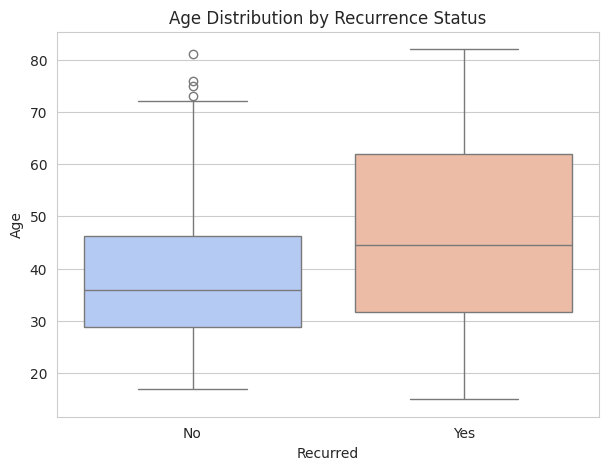

In [49]:
# Age vs. Recurrence (Boxplot)
plt.figure(figsize=(7, 5))
sns.boxplot(x='Recurred', y='Age', data=df_cleaned, palette='coolwarm')
plt.title('Age Distribution by Recurrence Status')
plt.xlabel('Recurred')
plt.ylabel('Age')
plt.show()

### Interpretación y Recomendación (Edad vs. Recurrencia)

**Interpretación:** El boxplot muestra que la mediana de edad para los pacientes que no experimentaron recurrencia ('No') es ligeramente menor que la de aquellos que sí experimentaron recurrencia ('Yes'). La dispersión de la edad también parece ser un poco más amplia para el grupo con recurrencia.

**Recomendación:** La edad podría ser un factor predictor importante para la recurrencia del cáncer de tiroides, con pacientes de mayor edad mostrando una tendencia a una mayor recurrencia. Los modelos de clasificación deberían poder capturar esta relación. No se recomienda eliminar esta variable, ya que tiene un claro valor predictivo potencial.

### Punto 9

Para cada variable categórica, decida y justifique la técnica de codificación apropiada (One-Hot, Ordinal o Binary
Encoding), considerando si la variable tiene orden natural, su cardinalidad, y qué algoritmos se van a usar (recuerde que
Label/Ordinal Encoding puede introducir un orden falso en modelos lineales o de distancia)



**1. Variables categóricas binarias**

Las variables `Gender`, `Smoking`, `Hx Smoking`, `Hx Radiothreapy`, `Focality` y `M` son variables binarias, ya que solamente tienen dos categorías posibles, por ejemplo, `Yes/No` o `Female/Male`.

Para estas variables se utilizó una **codificación binaria**, asignando valores de 0 y 1 a cada categoría. Esto es equivalente a utilizar Label Encoding. En este caso no hay problema de crear un orden falso, porque solamente existen dos categorías y la asignación de 0 y 1 no representa una jerarquía entre ellas.

Además, esta codificación permite trabajar con una sola columna por variable, en lugar de crear varias columnas como ocurriría con One-Hot Encoding. Esto puede ser conveniente para modelos lineales y modelos basados en distancia.

**2. Variables categóricas ordinales**

Las variables `Risk`, `T`, `N` y `Stage` se consideran variables ordinales porque sus categorías tienen un **orden natural y clínicamente significativo**.

Por ejemplo, en `Risk` existe una progresión como `Low < Intermediate < High`, mientras que en `T` categorías como `T1a`, `T1b`, `T2`, etc., representan diferentes niveles de extensión o severidad del tumor.

Para estas variables se utilizó **Ordinal Encoding**, asignando valores numéricos siguiendo el orden de las categorías. En este caso, la asignación numérica sí tiene sentido, ya que representa la progresión clínica de la enfermedad. Es decir, un valor mayor representa una mayor severidad o extensión cuando corresponde.

Este método permite que modelos lineales y modelos basados en distancia puedan utilizar la información del orden de las categorías. Además, evita crear demasiadas columnas mediante One-Hot Encoding, especialmente en variables que pueden tener varias categorías.

**3. Variables categóricas nominales**

Las variables `Thyroid Function`, `Physical Examination`, `Adenopathy`, `Pathology` y `Response` son variables nominales, ya que sus categorías **no tienen un orden natural o una jerarquía**.

Por ejemplo, en `Pathology`, categorías como `Papillary`, `Follicular` y `Hurthel cell` representan diferentes tipos de cáncer, pero no se puede decir que uno sea "mayor" o "menor" que otro. Son categorías diferentes sin una relación de magnitud.

Por esta razón, no sería adecuado utilizar Ordinal Encoding. Si, por ejemplo, se asignara `Papillary = 0`, `Micropapillary = 1`, `Follicular = 2` y `Hurthel cell = 3`, el modelo podría interpretar que existe una relación de orden entre ellas. En un modelo lineal esto podría hacer que los valores numéricos tengan diferentes pesos, y en un modelo basado en distancia, como KNN, se podría interpretar que algunas categorías están más "cerca" de otras, aunque realmente no exista esa relación.

Para evitar este problema se utilizó **One-Hot Encoding**, creando una columna para cada categoría. En estas nuevas columnas, el valor `1` indica que el registro pertenece a esa categoría y `0` indica que no pertenece.

Aunque One-Hot Encoding aumenta el número de columnas, es una forma adecuada de representar variables nominales porque **no introduce un orden artificial entre las categorías**.




In [50]:
df_encoded = df_cleaned.copy()

# 1. Variable objetivo
df_encoded['Recurred'] = df_encoded['Recurred'].map({'No': 0, 'Yes': 1})

# 2. Binarias Mapeo directo
binary_maps = {
    'Gender': {'F': 0, 'M': 1},
    'Smoking': {'No': 0, 'Yes': 1},
    'Hx Smoking': {'No': 0, 'Yes': 1},
    'Hx Radiothreapy': {'No': 0, 'Yes': 1},
    'Focality': {'Uni-Focal': 0, 'Multi-Focal': 1},
    'M': {'M0': 0, 'M1': 1},
}
for col, mapping in binary_maps.items():
    df_encoded[col] = df_encoded[col].map(mapping)

# 3. Ordinales Mapeo directo usando el orden clínico definido
ordinal_orders = {
    'Risk': ['Low', 'Intermediate', 'High'],
    'T': ['T1a', 'T1b', 'T2', 'T3a', 'T3b', 'T4a', 'T4b'],
    'N': ['N0', 'N1a', 'N1b'],
    'Stage': ['I', 'II', 'III', 'IVA', 'IVB'],
}
for col, order in ordinal_orders.items():
    df_encoded[col] = df_encoded[col].map({cat: i for i, cat in enumerate(order)})

# 4. Nominales  One-Hot con pandas
nominal_features = ['Thyroid Function', 'Physical Examination', 'Adenopathy', 'Pathology', 'Response']
df_encoded = pd.get_dummies(df_encoded, columns=nominal_features, dtype=int)

display(df_encoded.head())


,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Focality,Risk,T,N,M,...,Adenopathy_Posterior,Adenopathy_Right,Pathology_Follicular,Pathology_Hurthel cell,Pathology_Micropapillary,Pathology_Papillary,Response_Biochemical Incomplete,Response_Excellent,Response_Indeterminate,Response_Structural Incomplete
0,27,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
1,34,0,0,1,0,0,0,0,0,0,...,0,0,0,0,1,0,0,1,0,0
2,30,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,1,0,0
3,62,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,1,0,0
4,62,0,0,0,0,1,0,0,0,0,...,0,0,0,0,1,0,0,1,0,0


### Punto 10
Decida y justifique si es necesario escalar las variables numéricas y con qué técnica (Min-Max, StandardScaler o
RobustScaler), considerando la presencia de outliers detectada en el punto 7 y los algoritmos que va a entrenar
(recuerde que KNN y la regresión son sensibles a la escala; los árboles no)



1.  **Variables Numéricas:**
    *   **Variable:** `Age`.
    *   **Justificación:** `Age` es la única variable numérica en el dataset. Previamente, se determinó que no presenta outliers significativos según el criterio IQR (Punto 7). Aunque los modelos basados en árboles (como Random Forest) no son sensibles a la escala de las características, los modelos lineales (como la Regresión Logística), que son comunes en problemas de clasificación, sí lo son. Sin escalar, las características con rangos de valores más grandes pueden dominar la función de pérdida del modelo, llevando a que los pesos se ajusten de manera desproporcionada.
    *   **Técnica Elegida:** **StandardScaler**. Esta técnica es adecuada porque la distribución de la edad, aunque ligeramente sesgada, no contiene outliers extremos. `StandardScaler` transforma los datos para que tengan una media de 0 y una desviación estándar de 1. Esto es beneficioso para modelos que asumen una distribución normal de los datos o que calculan distancias entre puntos (como KNN, si se llegara a usar, o SVM, o métodos que se basan en la optimización de gradiente). Al no haber outliers extremos, no es necesario un `RobustScaler`, que es más resistente a ellos. `Min-Max Scaler` podría ser una alternativa, pero `StandardScaler` es generalmente preferido cuando las distribuciones son cercanas a la normal y no hay outliers para garantizar que todas las características contribuyan equitativamente al entrenamiento del modelo.

Esta transformación asegurará que la variable `Age` contribuya de manera justa al proceso de entrenamiento de modelos sensibles a la escala.

In [51]:
# La columna 'Age' es la única variable numérica del dataset
scaler = StandardScaler()

# Aplicar el escalado solo a la columna 'Age'
df_encoded['Age_scaled'] = scaler.fit_transform(df_encoded[['Age']])

print("Comparación de 'Age' original vs escalada:")
display(df_encoded[['Age', 'Age_scaled']].head())

# Se elimina la columna original 'Age' para evitar duplicar la misma información
# al momento de entrenar los modelos (dejar solo la versión escalada)
df_encoded = df_encoded.drop(columns=['Age'])

print("\nDataFrame final, con 'Age' ya escalada (primeras 5 filas):")
display(df_encoded.head())

Comparación de 'Age' original vs escalada:


,Age,Age_scaled
0,27,-0.931780
1,34,-0.474064
2,30,-0.735616
3,62,1.356803
4,62,1.356803



DataFrame final, con 'Age' ya escalada (primeras 5 filas):


,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Focality,Risk,T,N,M,Stage,...,Adenopathy_Right,Pathology_Follicular,Pathology_Hurthel cell,Pathology_Micropapillary,Pathology_Papillary,Response_Biochemical Incomplete,Response_Excellent,Response_Indeterminate,Response_Structural Incomplete,Age_scaled
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,1,0,-0.931780
1,0,0,1,0,0,0,0,0,0,0,...,0,0,0,1,0,0,1,0,0,-0.474064
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,1,0,0,-0.735616
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,1,0,0,1.356803
4,0,0,0,0,1,0,0,0,0,0,...,0,0,0,1,0,0,1,0,0,1.356803


# **Fase  2 — División de datos y Pipelines**

###Punto 11
Divida cada dataset en train / validation / test (ej. 70/15/15). Explique con sus palabras el propósito de cada uno de los
tres conjuntos y por qué no basta con solo train/test.

In [52]:
# Separar variables predictoras (X) y variable objetivo (y)
# Se usa df_cleaned (datos originales, sin las transformaciones manuales de fases anteriores),
# porque el preprocesamiento ahora se hará dentro del Pipeline
X = df_cleaned.drop(columns=['Recurred'])
y = df_cleaned['Recurred'].map({'No': 0, 'Yes': 1})

# Paso 1: separar Test (15%) del resto (85%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42,
    stratify=y  # mantiene la proporción de clases (Recurred) en cada conjunto
)

# Paso 2: del 85% restante, separar Train (70% del total) y Validation (15% del total)
val_ratio = 0.15 / 0.85
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=val_ratio,
    random_state=42,
    stratify=y_temp
)

print(f"Train: {X_train.shape[0]} filas ({X_train.shape[0]/len(X):.1%})")
print(f"Validation: {X_val.shape[0]} filas ({X_val.shape[0]/len(X):.1%})")
print(f"Test: {X_test.shape[0]} filas ({X_test.shape[0]/len(X):.1%})")

print("\nProporción de 'Recurred' en cada conjunto:")
print(f"Train: {y_train.mean():.3f} | Val: {y_val.mean():.3f} | Test: {y_test.mean():.3f}")

Train: 254 filas (69.8%)
Validation: 55 filas (15.1%)
Test: 55 filas (15.1%)

Proporción de 'Recurred' en cada conjunto:
Train: 0.299 | Val: 0.291 | Test: 0.291


### ¿Por qué no basta con Train/Test?

- **Train (70%)**: es el conjunto que el modelo ve directamente durante el entrenamiento.
  Aquí se ajustan los parámetros internos del algoritmo (coeficientes en regresión,
  splits en árboles, etc.).

- **Validation (15%)**: se usa para tomar decisiones sobre el modelo mientras se está
  desarrollando: comparar distintos algoritmos, ajustar hiperparámetros (ej. profundidad
  de un árbol, K en KNN, regularización en regresión logística), o decidir cuándo detener
  el entrenamiento. El modelo no se entrena con estos datos, pero se usa repetidamente
  para evaluar y ajustar decisiones, por lo que indirectamente se filtra información
  de este conjunto hacia el proceso de selección del modelo.

- **Test (15%)**: se reserva exclusivamente para la evaluación final, una sola vez,
  después de que el modelo y sus hiperparámetros ya quedaron completamente definidos.
  Simula cómo se comportaría el modelo con pacientes completamente nuevos, nunca vistos
  ni siquiera indirectamente durante el desarrollo.

**El problema de usar solo Train/Test:** si se ajustan hiperparámetros o se elige el
mejor modelo comparando el desempeño directamente sobre el conjunto de Test, ese conjunto
deja de ser una medida limpia del desempeño en datos nuevos, el modelo terminaría optimizado indirectamente para ese Test específico (una forma sutil de overfitting/data
leakage a nivel de selección de modelo). El conjunto de Validation existe precisamente
para absorber ese proceso iterativo de ajuste, dejando el Test verdaderamente intacto
para una evaluación final honesta.

In [53]:
# Definición de grupos de variables
numeric_features = ['Age']

binary_features = ['Gender', 'Smoking', 'Hx Smoking', 'Hx Radiothreapy', 'Focality', 'M']

ordinal_features = ['Risk', 'T', 'N', 'Stage']
ordinal_orders = [
    ['Low', 'Intermediate', 'High'],                          # Risk
    ['T1a', 'T1b', 'T2', 'T3a', 'T3b', 'T4a', 'T4b'],           # T
    ['N0', 'N1a', 'N1b'],                                      # N
    ['I', 'II', 'III', 'IVA', 'IVB'],                          # Stage
]

nominal_features = ['Thyroid Function', 'Physical Examination', 'Adenopathy', 'Pathology', 'Response']

# Sub-pipeline: variables numéricas (imputación + escalamiento)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # mediana: robusta ante posible asimetría/outliers
    ('scaler', StandardScaler())
])

# Sub-pipeline: variables binarias (imputación + encoding 0/1)
binary_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # moda, ya que son categóricas
    ('encoder', OneHotEncoder(drop='if_binary', handle_unknown='ignore'))
])

# Sub-pipeline: variables ordinales (imputación + encoding con orden clínico)
ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=ordinal_orders,
                                handle_unknown='use_encoded_value', unknown_value=-1))
])

# Sub-pipeline: variables nominales (imputación + One-Hot)
nominal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Ensamblar todo en un ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('bin', binary_transformer, binary_features),
    ('ord', ordinal_transformer, ordinal_features),
    ('nom', nominal_transformer, nominal_features)
])

# Pipeline completo (preprocesamiento))
full_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor)
])

# Ajustar (fit) solo con X_train
X_train_processed = full_pipeline.fit_transform(X_train)

# Aplicar (transform) sobre Validation y Test, sin volver a ajustar
X_val_processed = full_pipeline.transform(X_val)
X_test_processed = full_pipeline.transform(X_test)

print(f"Forma de X_train procesado: {X_train_processed.shape}")
print(f"Forma de X_val procesado:   {X_val_processed.shape}")
print(f"Forma de X_test procesado:  {X_test_processed.shape}")

Forma de X_train procesado: (254, 35)
Forma de X_val procesado:   (55, 35)
Forma de X_test procesado:  (55, 35)


###Punto 13
Verifique explícitamente en una celda de texto que su implementación NO tiene fuga de datos (data leakage): confirme
que el .fit() de cada transformación se realizó solo sobre X_train, y que sobre X_val y X_test únicamente se aplicó
.transform().


### Verificación de ausencia de Data Leakage

Se verificó que el proceso no presenta **Data Leakage**, ya que el preprocesamiento se realizó de forma separada entre Train, Validation y Test.

1. **`fit()` solo se realizó sobre `X_train`:** con `full_pipeline.fit_transform(X_train)` se calcularon únicamente con los datos de entrenamiento los valores necesarios para la imputación, el escalamiento y la codificación.

2. **En Validation y Test solo se utilizó `transform()`:** `X_val` y `X_test` utilizaron los parámetros aprendidos con `X_train`, sin volver a calcularlos. De esta forma, estos conjuntos no aportaron información al proceso de entrenamiento.

3. **Importancia de esto:** si se hubiera aplicado `fit_transform()` a todo el dataset antes de dividirlo, el preprocesamiento habría utilizado información de Validation y Test. Esto produciría Data Leakage y podría hacer que el modelo mostrara un rendimiento artificialmente mejor.

4. **Consistencia de las categorías:** se utilizó `handle_unknown='ignore'` en los encoders. Así, si aparece una categoría en Validation o Test que no estaba en Train, el pipeline no falla ni aprende de ella.

**Conclusión:** al aplicar `fit_transform()` únicamente a Train y `transform()` a Validation y Test, se mantiene una separación correcta de los datos y se evita el Data Leakage.


# **Fase  4 — Modelado: Clasificación (Thyroid Disease Data)**

###Punto 16
Entrene los siguientes modelos sobre el conjunto de entrenamiento para predecir el diagnóstico: KNN Classifier,
Decision Tree Classifier, Random Forest Classifier y Gradient Boosting Classifier

In [54]:
models = {
    'KNN': KNeighborsClassifier(), # KNN does not have a class_weight parameter
    'Decision Tree': DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(random_state=42, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVM': SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42, class_weight='balanced')
}

for name, model in models.items():
    model.fit(X_train_processed, y_train)
    print(f" {name} entrenado correctamente.")

 KNN entrenado correctamente.
 Decision Tree entrenado correctamente.
 Random Forest entrenado correctamente.
 Gradient Boosting entrenado correctamente.
 SVM entrenado correctamente.


###Punto 17
Para cada modelo, genere las predicciones sobre el conjunto de validación.

In [55]:
# Predicciones de clase (0 = No recurrió, 1 = Sí recurrió) sobre validación
predictions_val = {}

for name, model in models.items():
    y_pred_val = model.predict(X_val_processed)
    predictions_val[name] = y_pred_val
    print(f"\n{name} — primeras 10 predicciones en validación:")
    print(y_pred_val[:10])


KNN — primeras 10 predicciones en validación:
[1 0 0 0 0 0 0 0 0 1]

Decision Tree — primeras 10 predicciones en validación:
[1 0 0 0 0 0 0 0 0 1]

Random Forest — primeras 10 predicciones en validación:
[1 0 0 0 0 0 0 0 0 1]

Gradient Boosting — primeras 10 predicciones en validación:
[1 0 0 0 0 0 0 0 0 1]

SVM — primeras 10 predicciones en validación:
[1 0 0 0 0 0 0 0 0 1]


# **Fase 5 — Métricas en train y validación: detección de overfitting/underfitting**


### Punto 19
Clasificación: para cada uno de los 4 modelos, calcule Accuracy, Precision, Recall, F1-score y la matriz de confusión,
también sobre train y sobre validación. Compare ambos conjuntos por modelo para identificar overfitting o underfitting.
Interprete los resultados considerando que es un problema de diagnóstico médico: discuta qué es más costoso, un falso
positivo o un falso negativo, y qué métrica debería priorizarse.


Modelo: KNN
Train      -> Accuracy: 0.929 | Precision: 0.939 | Recall: 0.816 | F1: 0.873
Validation -> Accuracy: 0.945 | Precision: 0.933 | Recall: 0.875 | F1: 0.903


Modelo: Decision Tree
Train      -> Accuracy: 1.000 | Precision: 1.000 | Recall: 1.000 | F1: 1.000
Validation -> Accuracy: 0.964 | Precision: 1.000 | Recall: 0.875 | F1: 0.933


Modelo: Random Forest
Train      -> Accuracy: 1.000 | Precision: 1.000 | Recall: 1.000 | F1: 1.000
Validation -> Accuracy: 0.964 | Precision: 1.000 | Recall: 0.875 | F1: 0.933


Modelo: Gradient Boosting
Train      -> Accuracy: 1.000 | Precision: 1.000 | Recall: 1.000 | F1: 1.000
Validation -> Accuracy: 0.945 | Precision: 0.933 | Recall: 0.875 | F1: 0.903


Modelo: SVM
Train      -> Accuracy: 0.980 | Precision: 0.986 | Recall: 0.947 | F1: 0.966
Validation -> Accuracy: 0.964 | Precision: 1.000 | Recall: 0.875 | F1: 0.933



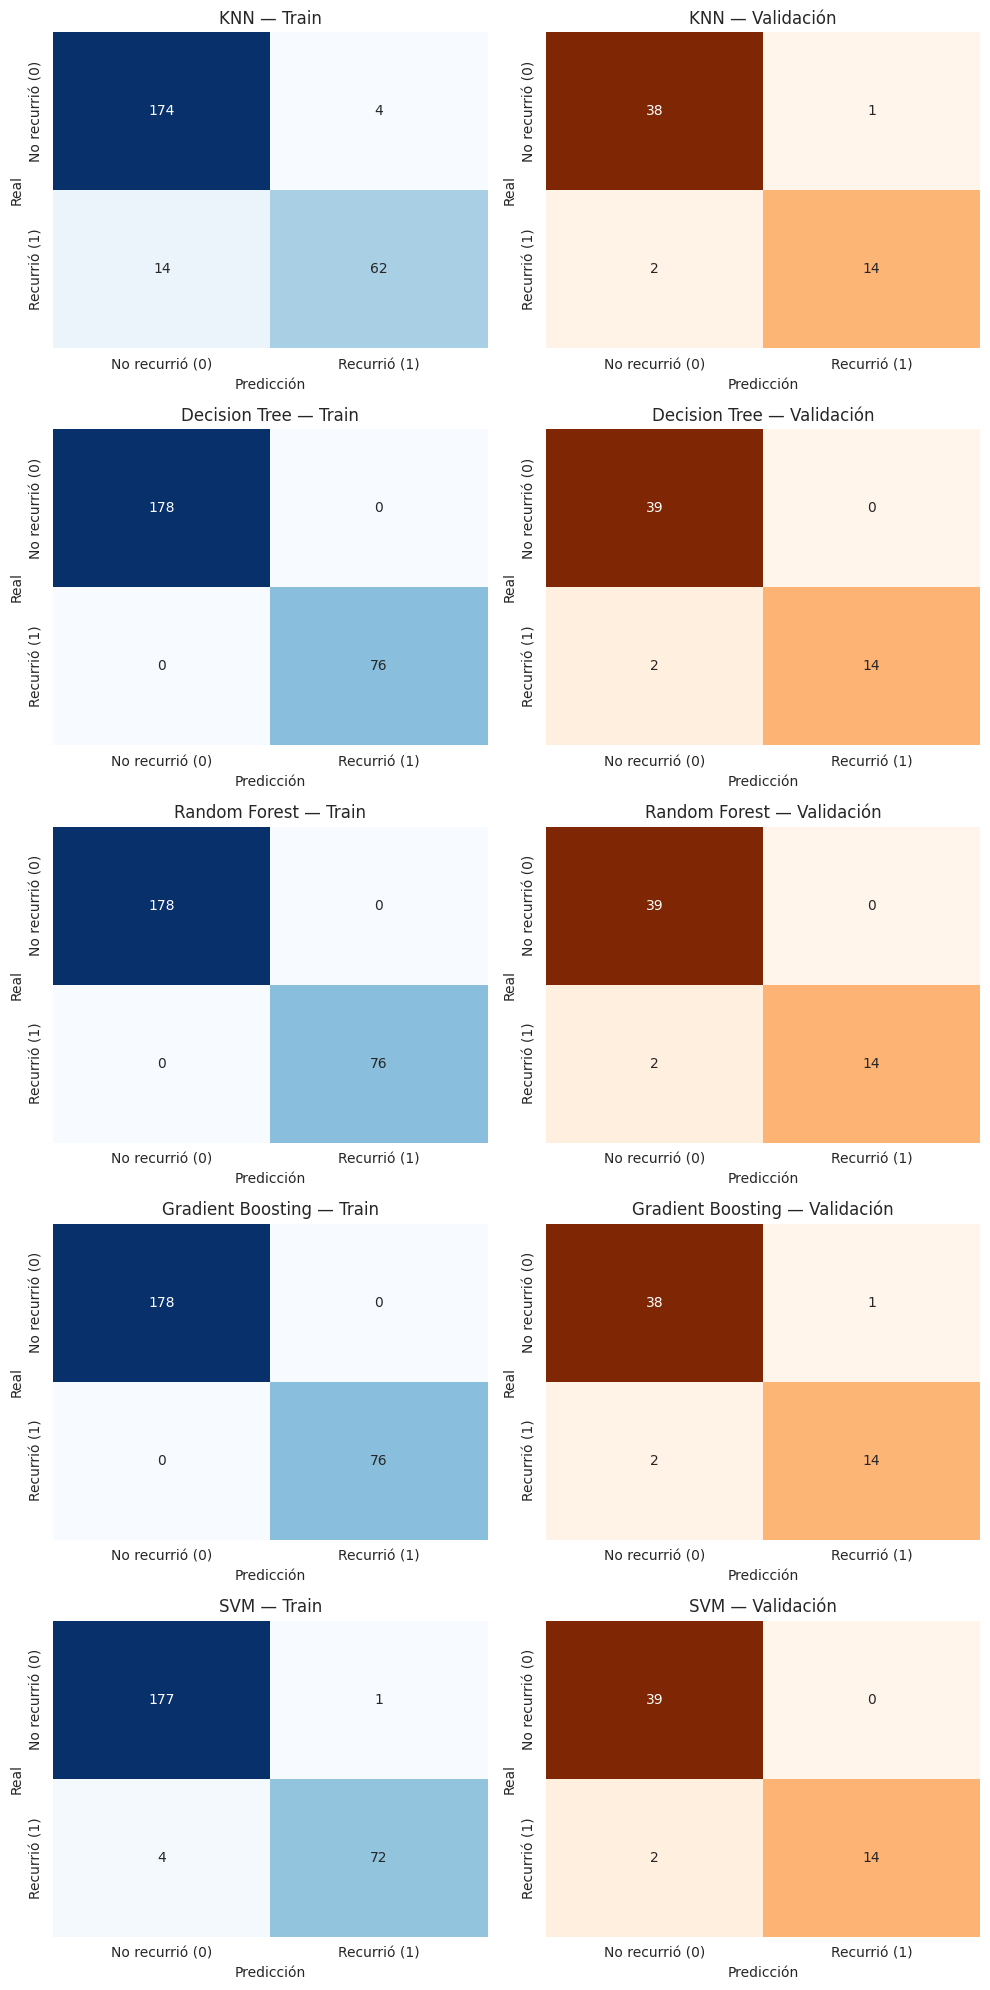

In [56]:
results_clf = []

n_models = len(models)
fig, axes = plt.subplots(n_models, 2, figsize=(10, 4 * n_models))
labels = ['No recurrió (0)', 'Recurrió (1)']

for i, (name, model) in enumerate(models.items()):
    y_pred_train = model.predict(X_train_processed)
    y_pred_val = model.predict(X_val_processed)

    # Métricas en train
    acc_train = accuracy_score(y_train, y_pred_train)
    prec_train = precision_score(y_train, y_pred_train)
    rec_train = recall_score(y_train, y_pred_train)
    f1_train = f1_score(y_train, y_pred_train)
    cm_train = confusion_matrix(y_train, y_pred_train)

    # Métricas en validación
    acc_val = accuracy_score(y_val, y_pred_val)
    prec_val = precision_score(y_val, y_pred_val)
    rec_val = recall_score(y_val, y_pred_val)
    f1_val = f1_score(y_val, y_pred_val)
    cm_val = confusion_matrix(y_val, y_pred_val)

    results_clf.append({
        'Modelo': name,
        'Accuracy_train': acc_train, 'Accuracy_val': acc_val,
        'Precision_train': prec_train, 'Precision_val': prec_val,
        'Recall_train': rec_train, 'Recall_val': rec_val,
        'F1_train': f1_train, 'F1_val': f1_val
    })

    print(f"\n{'='*50}\nModelo: {name}\n{'='*50}")
    print(f"Train      -> Accuracy: {acc_train:.3f} | Precision: {prec_train:.3f} | Recall: {rec_train:.3f} | F1: {f1_train:.3f}")
    print(f"Validation -> Accuracy: {acc_val:.3f} | Precision: {prec_val:.3f} | Recall: {rec_val:.3f} | F1: {f1_val:.3f}")
    print()

    # Matriz de confusión - Train
    sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=axes[i, 0], cbar=False)
    axes[i, 0].set_title(f'{name} — Train')
    axes[i, 0].set_xlabel('Predicción')
    axes[i, 0].set_ylabel('Real')

    # Matriz de confusión - Validación
    sns.heatmap(cm_val, annot=True, fmt='d', cmap='Oranges',
                xticklabels=labels, yticklabels=labels, ax=axes[i, 1], cbar=False)
    axes[i, 1].set_title(f'{name} — Validación')
    axes[i, 1].set_xlabel('Predicción')
    axes[i, 1].set_ylabel('Real')

plt.tight_layout()
plt.show()

### Análisis de los modelos y errores

**KNN:** En Train obtuvo Accuracy = 0.929, Precision = 0.939, Recall = 0.816 y F1 = 0.873. En Validation obtuvo 0.945, 0.933, 0.875 y 0.903, respectivamente. Como los resultados son muy similares e incluso mejores en Validation, **no se observa un overfitting significativo** y el modelo parece generalizar bien.

**Decision Tree:** En Train obtuvo 1.000 en todas las métricas, mientras que en Validation bajó a Accuracy = 0.945, Precision = 0.933, Recall = 0.875 y F1 = 0.903. Esta diferencia indica **overfitting**, ya que el árbol se ajustó demasiado a los datos de entrenamiento.

**Random Forest:** También obtuvo 1.000 en Train en todas las métricas. En Validation obtuvo Accuracy = 0.964, Precision = 1.000, Recall = 0.875 y F1 = 0.933. Presenta algo de **overfitting**, pero menor que Decision Tree. Su Precision perfecta indica que las predicciones de recurrencia fueron correctas, aunque su Recall muestra que todavía puede dejar sin detectar algunos casos reales.

**Gradient Boosting:** Al igual que Decision Tree, obtuvo 1.000 en Train y bajó a 0.945 de Accuracy, 0.933 de Precision, 0.875 de Recall y 0.903 de F1 en Validation, por lo que también presenta **overfitting**.

### Falsos positivos y falsos negativos

En este problema médico, un **falso positivo (FP)** ocurre cuando el modelo predice una recurrencia que realmente no existe. Esto puede generar preocupación en el paciente y llevar a pruebas o controles adicionales innecesarios.

Un **falso negativo (FN)** ocurre cuando el modelo predice que no habrá recurrencia cuando realmente sí existe. Este error es más grave, porque puede retrasar la detección y el tratamiento de la enfermedad.

Por esto, la métrica más importante sería el **Recall (Sensibilidad)**, ya que mide qué proporción de las recurrencias reales fueron detectadas y permite reducir los falsos negativos. Aunque Precision también es importante, en este caso es preferible detectar la mayor cantidad posible de casos reales. El **F1-score** también sirve para evaluar el equilibrio entre Precision y Recall.

### Conclusión

En general, **KNN presenta el menor overfitting y un buen equilibrio entre las métricas**. Random Forest obtiene el mejor resultado de Validation en Accuracy, Precision y F1, aunque su Recall sigue siendo 0.875. Los modelos de árboles presentan señales de overfitting, por lo que sería conveniente ajustar sus hiperparámetros para mejorar su generalización.


###Punto 20
Construya una tabla comparativa que incluya train y validación para regresión (filas: modelos, columnas:
MAE/MSE/R² en train y en val) y otra igual para clasificación (Accuracy/Precision/Recall/F1 en train y en val).


In [57]:
df_results_clf = pd.DataFrame(results_clf).set_index('Modelo')

# Reordenar columnas para que sea más legible (métrica agrupada por train/val)
df_results_clf = df_results_clf[[
    'Accuracy_train', 'Accuracy_val',
    'Precision_train', 'Precision_val',
    'Recall_train', 'Recall_val',
    'F1_train', 'F1_val'
]].round(3)

print("Tabla comparativa — Clasificación (Train vs. Validación)")
display(df_results_clf)

Tabla comparativa — Clasificación (Train vs. Validación)


,Accuracy_train,Accuracy_val,Precision_train,Precision_val,Recall_train,Recall_val,F1_train,F1_val
Modelo,,,,,,,,
KNN,0.929,0.945,0.939,0.933,0.816,0.875,0.873,0.903
Decision Tree,1.000,0.964,1.000,1.000,1.000,0.875,1.000,0.933
Random Forest,1.000,0.964,1.000,1.000,1.000,0.875,1.000,0.933
Gradient Boosting,1.000,0.945,1.000,0.933,1.000,0.875,1.000,0.903
SVM,0.980,0.964,0.986,1.000,0.947,0.875,0.966,0.933


###Punto 21
Seleccione el mejor modelo de cada problema y justifique la elección — no se limite a señalar la métrica más alta en
validación; discuta trade-offs (tiempo de entrenamiento, interpretabilidad, la señal de over/underfitting detectada en los
puntos anteriores) apoyándose en lo visto en clase sobre cada algoritmo.

### Selección del mejor modelo

Para seleccionar el mejor modelo se tuvieron en cuenta las métricas de **Validation**, el posible *overfitting*, la interpretabilidad y el contexto médico. En este caso, los **falsos negativos (FN)** son más graves que los falsos positivos, porque significan que no se detectó una recurrencia real. Por esto, la métrica más importante es el **Recall**, ya que busca detectar la mayor cantidad posible de casos positivos.

* **KNN:** obtuvo Accuracy = 0.945, Precision = 0.933, Recall = 0.875 y F1 = 0.903 en Validation. Es el modelo con **menor overfitting**, ya que sus resultados de Train y Validation son similares. Además, es relativamente sencillo y funciona bien en este dataset, aunque puede ser más lento con datos muy grandes o con muchas variables.

* **Decision Tree:** obtuvo las mismas métricas de Validation que KNN, pero presenta **overfitting fuerte**, ya que obtuvo 1.000 en todas las métricas de Train. Aunque es fácil de interpretar mediante reglas, necesitaría ajustar sus hiperparámetros para mejorar su generalización.

* **Random Forest:** obtuvo los mejores resultados de Validation en Accuracy = 0.964, Precision = 1.000 y F1 = 0.933. Sin embargo, su Recall = 0.875 es igual al de KNN, por lo que todavía puede dejar algunos casos de recurrencia sin detectar. También presenta overfitting, aunque menor que un árbol individual. Es más robusto, pero menos interpretable que Decision Tree.

* **Gradient Boosting:** obtuvo Accuracy = 0.945, Precision = 0.933, Recall = 0.875 y F1 = 0.903 en Validation. Presenta overfitting y no supera a KNN o Random Forest en este caso. Además, es un modelo más complejo y puede requerir mayor ajuste.



En esta primera evaluación, se selecciona **KNN como el mejor modelo**, principalmente porque tiene un **Recall de 0.875**, igual al de Random Forest, pero presenta menor diferencia entre Train y Validation, lo que indica una mejor generalización.

Aunque Random Forest tiene mejor Accuracy, Precision y F1, su Recall no mejora, y en un problema médico es especialmente importante reducir los falsos negativos. Además, KNN permite explicar el resultado mediante la similitud con otros pacientes.

Sin embargo, los modelos de árboles podrían mejorar mediante **ajuste de hiperparámetros**, especialmente buscando reducir el overfitting y aumentar el Recall. Esto podría cambiar la selección del mejor modelo en una etapa posterior.


# **Fase 6 — Evaluación final en el conjunto de Test**


###Punto 22
Evalúe TODOS los modelos entrenados de clasificación sobre el conjunto de test, usando las
mismas métricas calculadas en la Fase 5.


Modelo: KNN
Test -> Accuracy: 0.945 | Precision: 0.933 | Recall: 0.875 | F1: 0.903


Modelo: Decision Tree
Test -> Accuracy: 0.945 | Precision: 0.842 | Recall: 1.000 | F1: 0.914


Modelo: Random Forest
Test -> Accuracy: 0.964 | Precision: 0.938 | Recall: 0.938 | F1: 0.938


Modelo: Gradient Boosting
Test -> Accuracy: 0.964 | Precision: 0.889 | Recall: 1.000 | F1: 0.941


Modelo: SVM
Test -> Accuracy: 0.982 | Precision: 0.941 | Recall: 1.000 | F1: 0.970



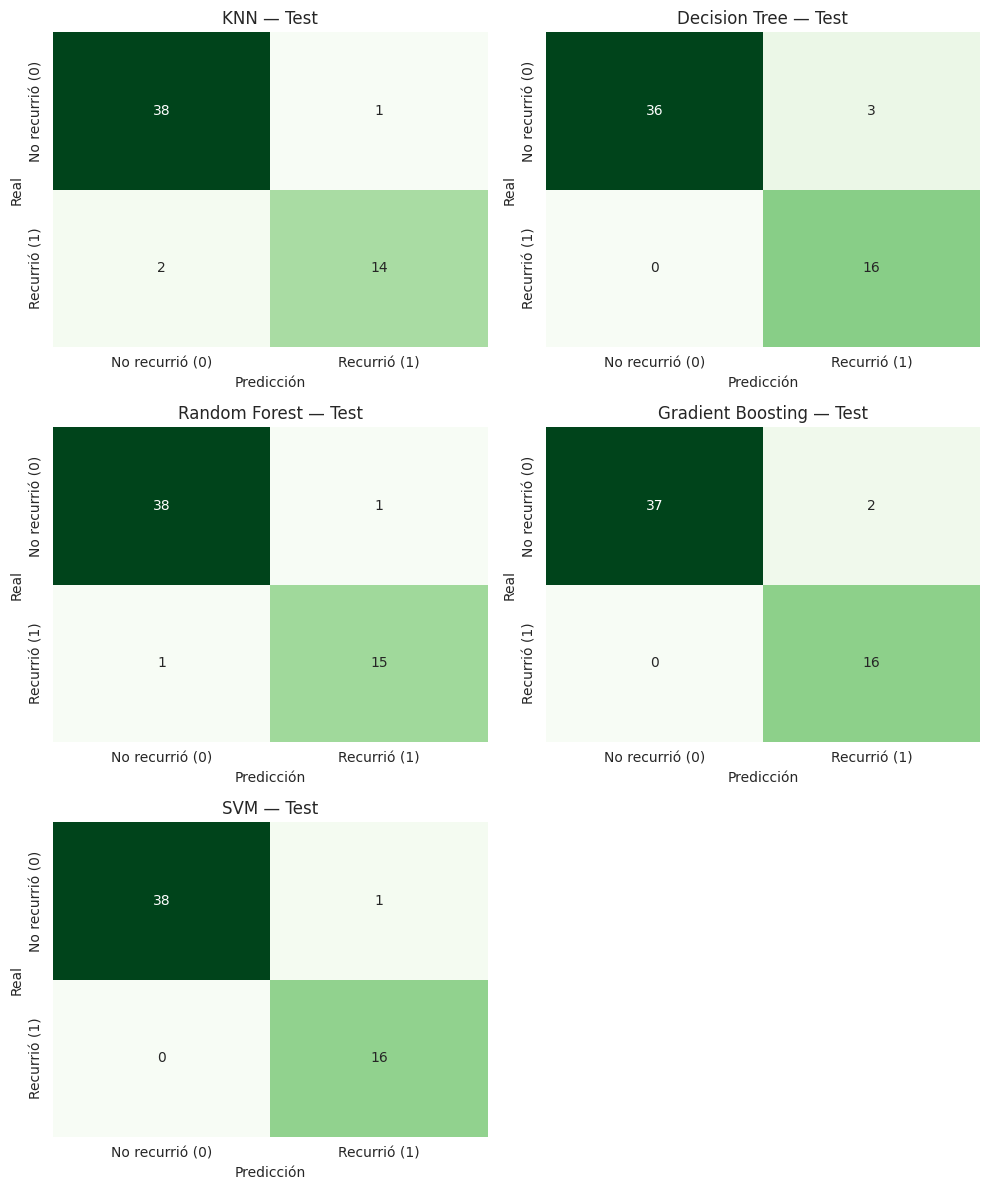


Tabla de resultados en TEST:


,Accuracy_test,Precision_test,Recall_test,F1_test
Modelo,,,,
KNN,0.945,0.933,0.875,0.903
Decision Tree,0.945,0.842,1.000,0.914
Random Forest,0.964,0.938,0.938,0.938
Gradient Boosting,0.964,0.889,1.000,0.941
SVM,0.982,0.941,1.000,0.970


In [58]:
import math

results_test_clf = []

n_models = len(models)
n_cols = 2
n_rows = math.ceil(n_models / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 4 * n_rows))
axes = axes.flatten()
labels = ['No recurrió (0)', 'Recurrió (1)']

for i, (name, model) in enumerate(models.items()):
    y_pred_test = model.predict(X_test_processed)

    acc_test = accuracy_score(y_test, y_pred_test)
    prec_test = precision_score(y_test, y_pred_test)
    rec_test = recall_score(y_test, y_pred_test)
    f1_test = f1_score(y_test, y_pred_test)
    cm_test = confusion_matrix(y_test, y_pred_test)

    results_test_clf.append({
        'Modelo': name,
        'Accuracy_test': acc_test,
        'Precision_test': prec_test,
        'Recall_test': rec_test,
        'F1_test': f1_test
    })

    print(f"\n{'='*50}\nModelo: {name}\n{'='*50}")
    print(f"Test -> Accuracy: {acc_test:.3f} | Precision: {prec_test:.3f} | Recall: {rec_test:.3f} | F1: {f1_test:.3f}")
    print()

    sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens',
                xticklabels=labels, yticklabels=labels, ax=axes[i], cbar=False)
    axes[i].set_title(f'{name} — Test')
    axes[i].set_xlabel('Predicción')
    axes[i].set_ylabel('Real')

# Ocultar subplots vacíos (si el número de modelos no llena la cuadrícula completa)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

df_results_test_clf = pd.DataFrame(results_test_clf).set_index('Modelo').round(3)
print("\nTabla de resultados en TEST:")
display(df_results_test_clf)

###Punto 23

Construya una tabla comparativa final con los resultados en test para cada problema, y compárela contra la tabla de
validación de la Fase 5: ¿el orden/ranking de los modelos se mantiene igual? ¿las métricas del mejor modelo en test son
consistentes con las que obtuvo en validación, o hay una diferencia importante? Interprete qué significaría una
diferencia grande entre val y test.

In [59]:
# Extraer solo las columnas de validación de la tabla que ya tenia
df_val_only = df_results_clf[['Accuracy_val', 'Precision_val', 'Recall_val', 'F1_val']]

# Combinar validación y test lado a lado
df_val_vs_test = df_val_only.join(df_results_test_clf)

# Reordenar para que quede Accuracy_val, Accuracy_test, Precision_val, Precision_test
df_val_vs_test = df_val_vs_test[[
    'Accuracy_val', 'Accuracy_test',
    'Precision_val', 'Precision_test',
    'Recall_val', 'Recall_test',
    'F1_val', 'F1_test'
]]

print("Tabla comparativa final — Validación vs. Test")
display(df_val_vs_test)

# Calcular la diferencia (val - test) para cada métrica, útil para detectar inconsistencias
df_diff = pd.DataFrame({
    'Diff_Accuracy': df_val_vs_test['Accuracy_val'] - df_val_vs_test['Accuracy_test'],
    'Diff_Precision': df_val_vs_test['Precision_val'] - df_val_vs_test['Precision_test'],
    'Diff_Recall': df_val_vs_test['Recall_val'] - df_val_vs_test['Recall_test'],
    'Diff_F1': df_val_vs_test['F1_val'] - df_val_vs_test['F1_test'],
})
print("\nDiferencia (Validación - Test) por modelo:")
display(df_diff.round(3))

Tabla comparativa final — Validación vs. Test


,Accuracy_val,Accuracy_test,Precision_val,Precision_test,Recall_val,Recall_test,F1_val,F1_test
Modelo,,,,,,,,
KNN,0.945,0.945,0.933,0.933,0.875,0.875,0.903,0.903
Decision Tree,0.964,0.945,1.000,0.842,0.875,1.000,0.933,0.914
Random Forest,0.964,0.964,1.000,0.938,0.875,0.938,0.933,0.938
Gradient Boosting,0.945,0.964,0.933,0.889,0.875,1.000,0.903,0.941
SVM,0.964,0.982,1.000,0.941,0.875,1.000,0.933,0.970



Diferencia (Validación - Test) por modelo:


,Diff_Accuracy,Diff_Precision,Diff_Recall,Diff_F1
Modelo,,,,
KNN,0.000,0.000,0.000,0.000
Decision Tree,0.019,0.158,-0.125,0.019
Random Forest,0.000,0.062,-0.063,-0.005
Gradient Boosting,-0.019,0.044,-0.125,-0.038
SVM,-0.018,0.059,-0.125,-0.037


Al comparar los resultados de Validación y Test, se puede ver si los modelos realmente generalizan bien a datos nuevos.

**1. ¿Se mantiene el mismo ranking?**

No. En Validación se había elegido KNN porque tenía buen rendimiento y poco overfitting. Sin embargo, en Test el ranking cambia:

KNN: mantiene un Recall de 0.875.

Decision Tree: mejora su Recall a 1.000.

Random Forest: mejora su Recall a 0.938.

Gradient Boosting: también alcanza un Recall de 1.000.

Esto muestra que los modelos basados en árboles detectaron más casos de recurrencia en el conjunto de Test.

**2. ¿Los resultados son consistentes?**

KNN: sus métricas son prácticamente iguales en Validación y Test, lo que indica una buena capacidad de generalización.

Decision Tree y Gradient Boosting: mejoran el Recall en Test, pero disminuyen la Precision, es decir, detectan más recurrencias, aunque también generan más falsos positivos.

Random Forest: mejora tanto el Recall como el F1-score, aunque su Precision baja un poco.

**3. ¿Qué significa una diferencia grande entre Validación y Test?**

Una diferencia importante puede indicar que el conjunto de Validación no era totalmente representativo, que hubo cierto ajuste al conjunto de Validación o simplemente que existe variabilidad por el tamaño o la distribución de los datos.


Los resultados de Test muestran que Gradient Boosting y Decision Tree obtienen el mejor Recall (1.000), que es la métrica más importante en este problema porque ayuda a minimizar los falsos negativos. Sin embargo, esto ocurre a costa de una menor Precision. KNN sigue siendo el modelo más consistente entre Validación y Test, mientras que Random Forest ofrece un buen equilibrio entre Recall y Precision.

# **Fase 7 — Cross Validation**


##Punto 24

Investigue y explique con sus propias palabras qué es la validación cruzada (K-Fold Cross Validation), cómo funciona
y por qué puede dar una estimación más confiable del desempeño de un modelo que un único split de train/validation.


### Validación Cruzada (K-Fold Cross Validation)

La **validación cruzada K-Fold** es una técnica que permite evaluar un modelo de forma más confiable que un único split de Train y Validation. Consiste en dividir los datos en **K grupos (folds)** y entrenar y validar el modelo varias veces.

Por ejemplo, con **K = 5**, los datos se dividen en 5 partes. En cada iteración se utilizan 4 partes para entrenar y 1 para validar. Esto se repite hasta que cada parte haya sido utilizada una vez como validación. Al final se calcula el **promedio y la desviación estándar** de las métricas obtenidas.

Esta técnica es útil porque:

* **Reduce la dependencia de un solo split:** evita que el resultado dependa demasiado de qué pacientes quedaron en Train o Validation por azar.
* **Aprovecha mejor los datos:** cada registro se utiliza K-1 veces para entrenar y una vez para validar, algo importante cuando el dataset es pequeño, como este de 383 pacientes.
* **Mide la estabilidad del modelo:** una desviación estándar baja indica que el modelo tiene resultados similares en diferentes particiones, mientras que una alta indica mayor variabilidad.
* **Es especialmente útil en datasets pequeños:** un único conjunto de validación puede ser muy pequeño y no representar bien todos los casos. K-Fold permite evaluar el modelo desde diferentes particiones y obtener una estimación más robusta.

Un único split proporciona una sola visión del rendimiento del modelo, mientras que **K-Fold permite obtener varias evaluaciones y promediarlas**, dando un resultado más estable y representativo de cómo podría funcionar el modelo con nuevos pacientes.


###Punto 26

Implemente K-Fold Cross Validation sobre el mejor modelo encontrado para el problema de clasificación, usando las
métricas relevantes.

In [60]:
# Seleccionar automáticamente el mejor modelo según F1 en validación
best_model_name_clf = df_results_clf['F1_val'].idxmax()
best_model_clf = models[best_model_name_clf]

print(f"Mejor modelo de clasificación (según F1 en validación): {best_model_name_clf}")

# Definir métricas relevantes para el problema de clasificación
scoring_clf = ['accuracy', 'precision', 'recall', 'f1']

# StratifiedKFold: mantiene la proporción de clases (Recurred) en cada fold,
# importante porque el dataset probablemente está desbalanceado
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cross validation sobre X_train_processed / y_train
# (se usa train, ya que test debe permanecer intacto para la evaluación final ya hecha)
cv_results_clf = cross_validate(
    best_model_clf, X_train_processed, y_train,
    cv=skf, scoring=scoring_clf, return_train_score=False
)

# Resumen de resultados
print(f"\n{'='*50}\nK-Fold Cross Validation (K=5) — {best_model_name_clf}\n{'='*50}")
for metric in scoring_clf:
    scores = cv_results_clf[f'test_{metric}']
    print(f"{metric.capitalize():<12} -> Media: {scores.mean():.3f} | Desv. Estándar: {scores.std():.3f} | Folds: {np.round(scores, 3)}")

Mejor modelo de clasificación (según F1 en validación): Decision Tree

K-Fold Cross Validation (K=5) — Decision Tree
Accuracy     -> Media: 0.921 | Desv. Estándar: 0.012 | Folds: [0.941 0.922 0.902 0.922 0.92 ]
Precision    -> Media: 0.869 | Desv. Estándar: 0.036 | Folds: [0.933 0.824 0.857 0.867 0.867]
Recall       -> Media: 0.868 | Desv. Estándar: 0.042 | Folds: [0.875 0.933 0.8   0.867 0.867]
F1           -> Media: 0.868 | Desv. Estándar: 0.024 | Folds: [0.903 0.875 0.828 0.867 0.867]


###Punto 27

 Compare los resultados de cross validation contra el desempeño obtenido en el conjunto de validación original de la
Fase 5: ¿el desempeño mejora, empeora o se mantiene similar? ¿La desviación estándar entre folds sugiere que el
modelo es estable o sensible a qué datos recibe? Interprete.


In [61]:
# Extraer las métricas obtenidas en validación (Fase 5) para el mejor modelo
val_metrics_best = df_results_clf.loc[best_model_name_clf, ['Accuracy_val', 'Precision_val', 'Recall_val', 'F1_val']]

print(f"Comparación — {best_model_name_clf}")
print(f"\n{'Métrica':<12}{'Val (Fase 5)':<15}{'CV Media':<12}{'CV Std':<10}")
for metric in scoring_clf:
    val_value = val_metrics_best[f'{metric.capitalize()}_val'] if metric != 'accuracy' else val_metrics_best['Accuracy_val']
    cv_mean = cv_results_clf[f'test_{metric}'].mean()
    cv_std = cv_results_clf[f'test_{metric}'].std()
    print(f"{metric.capitalize():<12}{val_value:<15.3f}{cv_mean:<12.3f}{cv_std:<10.3f}")

Comparación — Decision Tree

Métrica     Val (Fase 5)   CV Media    CV Std    
Accuracy    0.964          0.921       0.012     
Precision   1.000          0.869       0.036     
Recall      0.875          0.868       0.042     
F1          0.933          0.868       0.024     


# **Fase 8 — Conclusiones**

## Conclusiones Generales del Estudio

### 1. Desempeño y selección del modelo

El estudio se enfocó en la **clasificación de la recurrencia del cáncer de tiroides**. Debido a que un **falso negativo (FN)** puede ser más grave que un falso positivo (FP), se priorizó el **Recall**, aunque también se consideraron Precision y F1-score.

En el conjunto de **Test**:

*   **SVM:** obtuvo el mejor Recall (**1.000**), la mayor Accuracy (**0.982**) y el mejor F1-score (**0.970**), con una excelente Precision de **0.941**. Este modelo logra identificar correctamente todos los casos de recurrencia, lo cual es crítico en este problema médico.
*   **Gradient Boosting:** también obtuvo un Recall perfecto (**1.000**), pero su F1-score (**0.941**) y Precision (**0.889**) fueron inferiores a los de SVM. Aunque minimiza los falsos negativos, lo hace a costa de más falsos positivos en comparación con SVM.
*   **Random Forest:** obtuvo un buen equilibrio con Recall de **0.938** y F1 de **0.938**. Es una opción robusta, pero no supera el desempeño de SVM en la métrica clave.
*   **Decision Tree:** obtuvo Recall = **1.000**, pero su Precision fue la más baja (**0.842**), indicando un mayor número de falsos positivos.
*   **KNN:** fue el modelo más estable entre Validation y Test, pero su Recall en Test (**0.875**) y F1-score (**0.903**) fueron menores en comparación con los otros modelos.

Por lo tanto, considerando la prioridad de minimizar los falsos negativos y el rendimiento general en el conjunto de test, el modelo **SVM es la mejor elección**, ya que logra un Recall perfecto mientras mantiene una alta Precision y el F1-score más alto.

### 2. Preprocesamiento

El preprocesamiento fue importante para obtener resultados confiables:

*   Se eliminaron **19 registros duplicados**.
*   Se utilizaron diferentes métodos de codificación según el tipo de variable: binaria, ordinal y One-Hot Encoding.
*   Se aplicó **StandardScaler** a `Age`, especialmente importante para modelos sensibles a la escala como KNN y SVM.
*   Se realizó una división **70/15/15 estratificada**, manteniendo la proporción de `Recurred` en Train, Validation y Test.

### 3. Limitaciones

El dataset es pequeño, con **364 registros únicos** y solo **55 casos en Test**, lo que puede generar variabilidad en las métricas. Además, existe **desbalance de clases** y no se realizó ajuste de hiperparámetros, por lo que los modelos podrían mejorar con técnicas como GridSearchCV o RandomizedSearchCV.

También sería útil realizar un **EDA más completo**, explorar ingeniería de características y analizar otras posibilidades de modelado.

### 4. Trabajo futuro

Como próximos pasos se propone:

*   Realizar ajuste de hiperparámetros para el modelo SVM para optimizar aún más su rendimiento.
*   Probar técnicas para el desbalance, como **SMOTE, ADASYN o cost-sensitive learning**.
*   Explorar nuevas características e interacciones.
*   Mejorar la interpretabilidad utilizando herramientas como **LIME o SHAP**.
*   Validar los modelos con un dataset externo y más grande.

### Conclusión final

El estudio muestra que el **modelo SVM es el más prometedor**, destacando por su capacidad para detectar todos los casos de recurrencia en el conjunto de test (Recall = 1.000) y obtener el mejor F1-score. Sin embargo, debido al tamaño del dataset, el desbalance y la falta de tuning, sería necesario realizar más pruebas antes de considerar estos modelos para un uso clínico real.

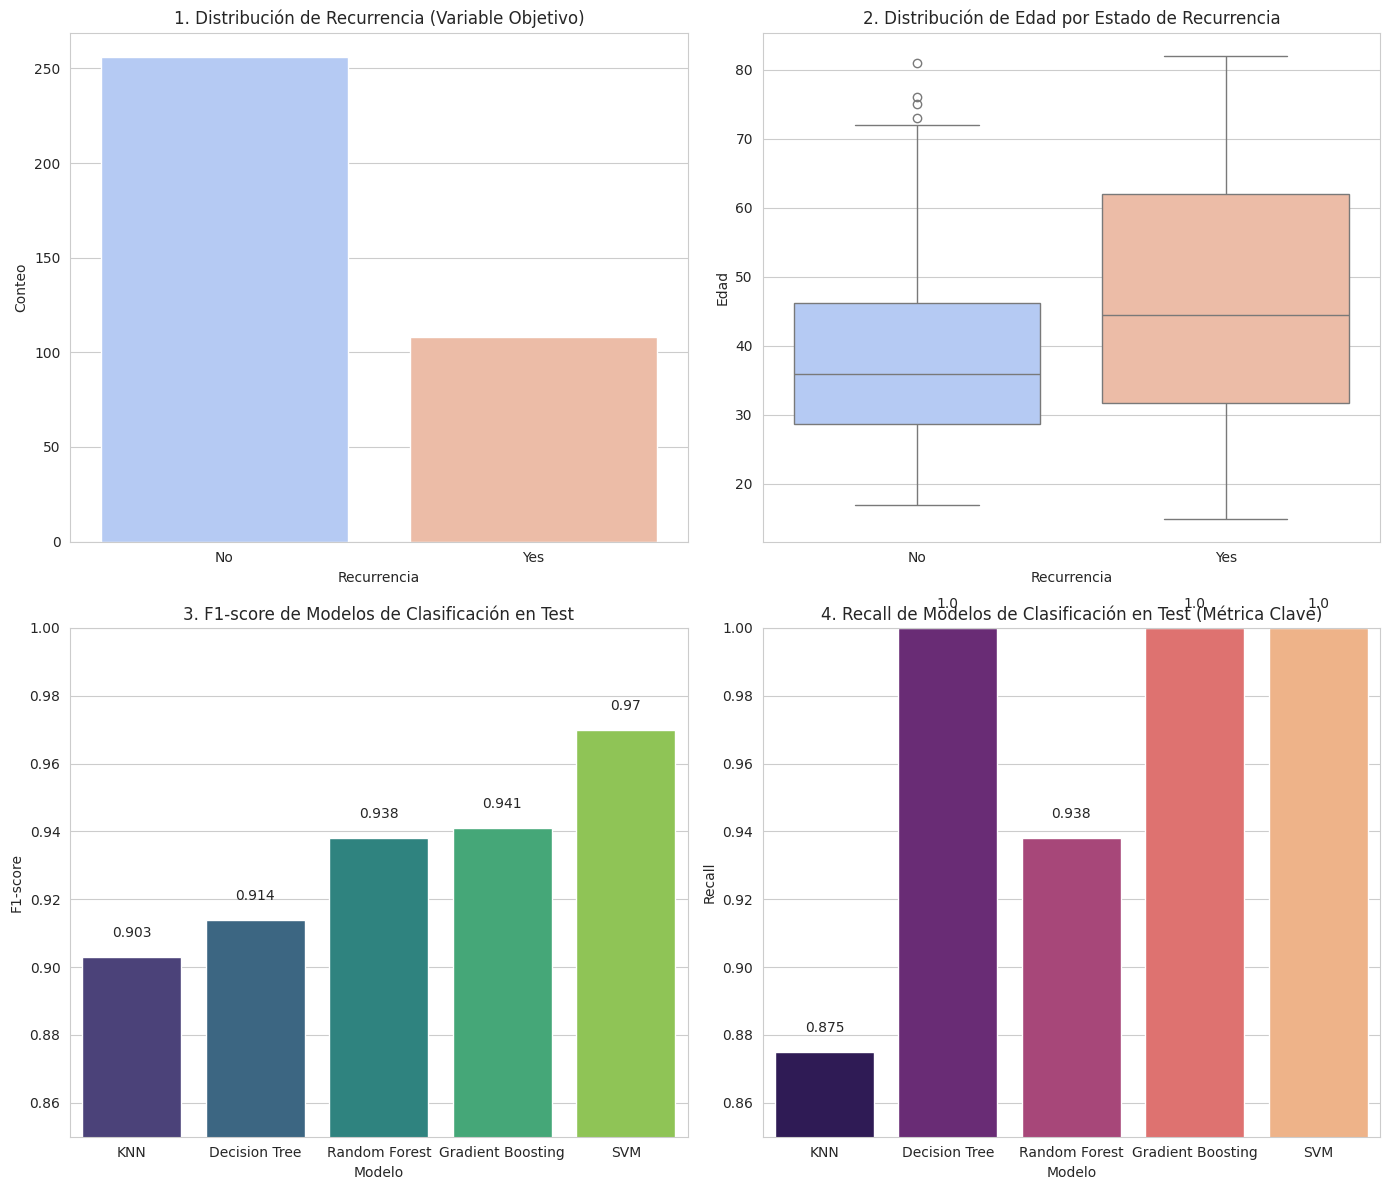

In [62]:
# Configuración de plots
sns.set_style("whitegrid")

# Creación del subplot 2x2
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

# Gráfico 1: Distribución de la variable objetivo 'Recurred' (desde EDA)
sns.countplot(x='Recurred', hue='Recurred', data=df_cleaned, palette='coolwarm',
              legend=False, ax=axes[0])
axes[0].set_title('1. Distribución de Recurrencia (Variable Objetivo)')
axes[0].set_xlabel('Recurrencia')
axes[0].set_ylabel('Conteo')

# Gráfico 2: Distribución de Edad por Estado de Recurrencia (desde EDA)
sns.boxplot(x='Recurred', y='Age', hue='Recurred', data=df_cleaned, palette='coolwarm',
            legend=False, ax=axes[1])
axes[1].set_title('2. Distribución de Edad por Estado de Recurrencia')
axes[1].set_xlabel('Recurrencia')
axes[1].set_ylabel('Edad')

# Gráfico 3: Comparación del F1-score en Test para Modelos de Clasificación
models_F1_test = df_results_test_clf['F1_test']
sns.barplot(x=models_F1_test.index, y=models_F1_test.values, hue=models_F1_test.index,
            palette='viridis', legend=False, ax=axes[2])
axes[2].set_title('3. F1-score de Modelos de Clasificación en Test')
axes[2].set_xlabel('Modelo')
axes[2].set_ylabel('F1-score')
axes[2].set_ylim(0.85, 1.0)
for index, value in enumerate(models_F1_test.values):
    axes[2].text(index, value + 0.005, str(round(value, 3)), ha='center', va='bottom')

# Gráfico 4: Comparación del Recall en Test para Modelos de Clasificación
models_recall_test = df_results_test_clf['Recall_test']
sns.barplot(x=models_recall_test.index, y=models_recall_test.values, hue=models_recall_test.index,
            palette='magma', legend=False, ax=axes[3])
axes[3].set_title('4. Recall de Modelos de Clasificación en Test (Métrica Clave)')
axes[3].set_xlabel('Modelo')
axes[3].set_ylabel('Recall')
axes[3].set_ylim(0.85, 1.0)
for index, value in enumerate(models_recall_test.values):
    axes[3].text(index, value + 0.005, str(round(value, 3)), ha='center', va='bottom')

plt.tight_layout()
plt.show()